# Paper figures and Table 1

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import beta, t


FIGURE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
if not (FIGURE_DIR / "paper_figures.py").exists():
    FIGURE_DIR = FIGURE_DIR / "analysis" / "figures"
ROOT = FIGURE_DIR.parents[1]
DATA = ROOT / "data"
RESULTS = ROOT / "analysis" / "results"
OUT = FIGURE_DIR / "output"
OUT.mkdir(parents=True, exist_ok=True)

COLORS = {
    "Human": "#4C78A8",
    "Robot": "#F58518",
    "Time": "#4C78A8",
    "Effort": "#54A24B",
}
CONDITION_COLORS = {
    "AI faster": "#F58518",
    "Human faster": "#4C78A8",
    "AI easier": "#F58518",
    "Human easier": "#4C78A8",
    "Fast/easy AI": "#1B9E77",
    "Slow/easy AI": "#D95F02",
    "Fast/hard AI": "#7570B3",
    "Slow/hard AI (first)": "#E7298A",
    "Slow/hard AI (second)": "#666666",
}
EXPERIMENT_1_TIME_CONDITIONS = {
    1: "AI faster",
    2: "Human faster",
}
EXPERIMENT_1_EFFORT_CONDITIONS = {
    2: "AI easier",
    1: "Human easier",
}
EXPERIMENT_2_CONDITIONS = {
    "optimal": "Fast/easy AI",
    "time_penalty": "Slow/easy AI",
    "effort_penalty": "Fast/hard AI",
    "full_suboptimal": "Slow/hard AI",
}

sns.set_theme(context="paper", style="whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


In [2]:
def load_data():
    time = pd.read_csv(DATA / "experiment_1" / "time_trials.csv")
    effort = pd.read_csv(DATA / "experiment_1" / "effort_trials.csv")
    tsa = pd.read_csv(DATA / "experiment_2" / "exp_2_by_trial.csv")
    time = time[time.groupby("subj_id")["subj_id"].transform("size").eq(16)].copy()
    effort = effort[effort.groupby("subj_id")["subj_id"].transform("size").eq(16)].copy()
    tsa = tsa[tsa.groupby("subj_id")["subj_id"].transform("size").eq(16)].copy()
    return time, effort, tsa


def mean_ci(values):
    values = pd.to_numeric(values, errors="coerce").dropna().to_numpy(float)
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    mean = values.mean()
    if len(values) == 1:
        return mean, mean, mean
    error = t.ppf(0.975, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values))
    return mean, mean - error, mean + error


def rate_ci(values):
    values = pd.to_numeric(values, errors="coerce").dropna()
    n = len(values)
    chosen = values.sum()
    if n == 0:
        return np.nan, np.nan, np.nan
    return (
        chosen / n,
        beta.ppf(0.025, chosen + 0.5, n - chosen + 0.5),
        beta.ppf(0.975, chosen + 0.5, n - chosen + 0.5),
    )


def participant_mode_stats(data, value):
    participant_means = data.groupby(
        ["condition", "mode", "subj_id"], as_index=False
    ).agg(value=(value, "mean"))
    return participant_means.groupby(["condition", "mode"])["value"].agg(["mean", "std"])


def experiment_1_table_rows(data, condition_labels):
    trials = data.assign(
        condition=data["block"].map(condition_labels),
        mode=np.where(data["select_robot"].eq(1), "with_ai", "no_ai"),
        time_s=data["round_total_time_ms"] / 1000,
    )
    time = participant_mode_stats(trials, "time_s")
    effort = participant_mode_stats(trials, "round_total_effort")
    n = trials["subj_id"].nunique()

    rows = []
    for condition in condition_labels.values():
        rows.append(
            {
                "experiment": "Experiment 1",
                "condition": condition,
                "n": n,
                "time_with_ai_mean": time.loc[(condition, "with_ai"), "mean"],
                "time_with_ai_sd": time.loc[(condition, "with_ai"), "std"],
                "time_no_ai_mean": time.loc[(condition, "no_ai"), "mean"],
                "time_no_ai_sd": time.loc[(condition, "no_ai"), "std"],
                "effort_with_ai_mean": effort.loc[(condition, "with_ai"), "mean"],
                "effort_with_ai_sd": np.nan,
                "effort_no_ai_mean": effort.loc[(condition, "no_ai"), "mean"],
                "effort_no_ai_sd": np.nan,
            }
        )
    return pd.DataFrame(rows)


def experiment_2_table_rows(data):
    first_block = data.loc[data["block_index"].eq(1)].assign(
        condition=data["first_condition"].map(EXPERIMENT_2_CONDITIONS),
        mode=data["mode"].replace({"ai": "with_ai", "manual": "no_ai"}),
    )
    assigned_n = first_block.groupby("condition")["subj_id"].nunique()

    time_data = first_block.loc[
        ~(first_block["idle_batch"] & first_block["mode"].eq("with_ai"))
    ]
    time = participant_mode_stats(time_data, "batch_time_sec")

    effort_data = first_block.loc[
        first_block["mode"].eq("with_ai")
        & first_block["snippets_hovered_count"].notna()
    ]
    effort = participant_mode_stats(effort_data, "snippets_hovered_count")

    rows = []
    for condition in EXPERIMENT_2_CONDITIONS.values():
        rows.append(
            {
                "experiment": "Experiment 2",
                "condition": condition,
                "n": assigned_n.loc[condition],
                "time_with_ai_mean": time.loc[(condition, "with_ai"), "mean"],
                "time_with_ai_sd": time.loc[(condition, "with_ai"), "std"],
                "time_no_ai_mean": time.loc[(condition, "no_ai"), "mean"],
                "time_no_ai_sd": time.loc[(condition, "no_ai"), "std"],
                "effort_with_ai_mean": effort.loc[(condition, "with_ai"), "mean"],
                "effort_with_ai_sd": effort.loc[(condition, "with_ai"), "std"],
                "effort_no_ai_mean": np.nan,
                "effort_no_ai_sd": np.nan,
            }
        )
    return pd.DataFrame(rows)


def build_table_1(experiment_1_time, experiment_1_effort, experiment_2):
    table = pd.concat(
        [
            experiment_1_table_rows(experiment_1_time, EXPERIMENT_1_TIME_CONDITIONS),
            experiment_1_table_rows(experiment_1_effort, EXPERIMENT_1_EFFORT_CONDITIONS),
            experiment_2_table_rows(experiment_2),
        ],
        ignore_index=True,
    )
    numeric_columns = table.columns.difference(["experiment", "condition", "n"])
    table[numeric_columns] = table[numeric_columns].round(4)
    return table


In [3]:
def save(fig, stem):
    for extension in ("png", "pdf"):
        fig.savefig(OUT / f"{stem}.{extension}", bbox_inches="tight", facecolor="white")
    return fig


def first_factory_block(data):
    trials = data.sort_values(["subj_id", "round_index"]).copy()
    trials["block_start"] = trials.groupby(["subj_id", "block"])["round_index"].transform("min")
    trials["block_number"] = trials.groupby("subj_id")["block_start"].rank(method="dense").astype(int)
    trials = trials[trials["block_number"].eq(1)].copy()
    trials["trial_window_index"] = trials.groupby("subj_id").cumcount() + 1
    trials["delegation_choice"] = trials["select_robot"].astype(float)
    trials["mode"] = np.where(trials["select_robot"].eq(1), "agent", "manual")
    trials["time_s"] = trials["round_total_time_ms"] / 1000
    trials["effort_clicks"] = trials["round_total_effort"].astype(float)
    return trials


def participant_delta(data, condition, value, mode, direction):
    means = data.groupby(["subj_id", condition, mode], as_index=False).agg(value=(value, "mean"))
    wide = means.pivot(index=["subj_id", condition], columns=mode, values="value").reset_index()
    complete = wide["agent"].notna() & wide["manual"].notna()
    if direction == "manual_minus_agent":
        wide["delta"] = wide["manual"] - wide["agent"]
    else:
        wide["delta"] = wide["agent"] - wide["manual"]
    return wide[complete].groupby(condition)["delta"].mean().to_dict()


def post_rates(data, experiment, panel, conditions, x_values):
    baseline = rate_ci(data.loc[data["trial_window_index"].eq(1), "delegation_choice"])[0]
    post = data[data["trial_window_index"].isin([7, 8])]
    rows = []
    for condition in conditions:
        rate, lower, upper = rate_ci(post.loc[post["condition"].eq(condition), "delegation_choice"])
        rows.append(
            {
                "experiment": experiment,
                "panel": panel,
                "condition": condition,
                "x": x_values[condition],
                "baseline": baseline,
                "rate": rate,
                "lower": lower,
                "upper": upper,
            }
        )
    return rows


def figure_1(time, effort, tsa):
    time = first_factory_block(time)
    time["condition"] = time["block"].map({1: "Robot faster", 2: "Human faster"})
    effort = first_factory_block(effort)
    effort["condition"] = effort["block"].map({1: "Human easier", 2: "Robot easier"})

    tsa = tsa[tsa["block_index"].eq(1)].copy()
    tsa["trial_window_index"] = tsa["batch_within_block"]
    tsa["delegation_choice"] = tsa["y"].astype(float)
    tsa["mode_simple"] = tsa["mode"].map({"ai": "agent", "manual": "manual"})
    tsa["accuracy"] = tsa["correct_count"] / tsa["n_trials"]
    tsa["condition"] = tsa["block_condition"].map(
        {
            "optimal": "Fast/easy AI",
            "time_penalty": "Slow/easy AI",
            "effort_penalty": "Fast/hard AI",
            "full_suboptimal": "Slow/hard AI",
        }
    )

    tsa_conditions = ["Fast/easy AI", "Slow/easy AI", "Fast/hard AI", "Slow/hard AI"]
    rows = []
    rows += post_rates(
        time,
        "Experiment 1",
        "Time",
        ["Robot faster", "Human faster"],
        participant_delta(time, "condition", "time_s", "mode", "manual_minus_agent"),
    )
    rows += post_rates(
        effort,
        "Experiment 1",
        "Effort",
        ["Robot easier", "Human easier"],
        participant_delta(effort, "condition", "effort_clicks", "mode", "manual_minus_agent"),
    )
    rows += post_rates(
        tsa,
        "Experiment 2",
        "Time",
        tsa_conditions,
        participant_delta(tsa, "condition", "batch_time_sec", "mode_simple", "manual_minus_agent"),
    )
    rows += post_rates(
        tsa,
        "Experiment 2",
        "Accuracy",
        tsa_conditions,
        participant_delta(tsa, "condition", "accuracy", "mode_simple", "agent_minus_manual"),
    )
    rows += post_rates(
        tsa,
        "Experiment 2",
        "Reward rate",
        tsa_conditions,
        participant_delta(tsa, "condition", "x_reward_rate", "mode_simple", "agent_minus_manual"),
    )
    summary = pd.DataFrame(rows)

    factory_colors = {
        "Robot faster": "#E69F00",
        "Human faster": "#56B4E9",
        "Robot easier": "#D55E00",
        "Human easier": "#009E73",
    }
    tsa_colors = {
        "Fast/easy AI": "#009E73",
        "Slow/easy AI": "#E69F00",
        "Fast/hard AI": "#CC79A7",
        "Slow/hard AI": "#777777",
    }
    fig = plt.figure(figsize=(4.2, 4.9), constrained_layout=True)
    outer = fig.add_gridspec(4, 1, height_ratios=[0.16, 1, 0.16, 1], hspace=0.02)
    for cell, label in ((outer[0], "A  Experiment 1"), (outer[2], "B  Experiment 2")):
        label_ax = fig.add_subplot(cell)
        label_ax.axis("off")
        label_ax.text(0, 0.5, label, fontsize=10, fontweight="bold", va="center")
    top_row = outer[1].subgridspec(1, 2, width_ratios=[1, 0.28], wspace=0.04)
    bottom_row = outer[3].subgridspec(1, 2, width_ratios=[1, 0.28], wspace=0.04)
    top = top_row[0, 0].subgridspec(1, 3, width_ratios=[2.55, 0.35, 2.55], wspace=0.06)
    bottom = bottom_row[0, 0].subgridspec(1, 3, wspace=0.10)
    axes = [fig.add_subplot(top[0, 0]), fig.add_subplot(top[0, 2])]
    spacer = fig.add_subplot(top[0, 1])
    spacer.axis("off")
    axes += [fig.add_subplot(bottom[0, i]) for i in range(3)]
    legends = [fig.add_subplot(top_row[0, 1]), fig.add_subplot(bottom_row[0, 1])]
    for legend in legends:
        legend.axis("off")

    specs = [
        (axes[0], "Experiment 1", "Time", "Δ time (s)"),
        (axes[1], "Experiment 1", "Effort", "Δ effort (clicks)"),
        (axes[2], "Experiment 2", "Time", "Δ time (s)"),
        (axes[3], "Experiment 2", "Accuracy", "Δ accuracy"),
        (axes[4], "Experiment 2", "Reward rate", "Δ reward rate\n(correct/min)"),
    ]
    for ax, experiment, panel, xlabel in specs:
        subset = summary[summary["experiment"].eq(experiment) & summary["panel"].eq(panel)]
        ax.axhline(subset["baseline"].iloc[0], color="#555555", linestyle=":", linewidth=1)
        ax.axvline(0, color="#BDBDBD", linewidth=0.8)
        for point in subset.itertuples():
            color = factory_colors.get(point.condition, tsa_colors.get(point.condition, "#333333"))
            ax.errorbar(
                point.x,
                point.rate,
                yerr=[[point.rate - point.lower], [point.upper - point.rate]],
                fmt="o",
                color=color,
                markeredgecolor="white",
                markeredgewidth=0.7,
                markersize=5.2,
                capsize=2,
                linewidth=0.75,
            )
        if panel == "Accuracy":
            ax.set_xticks([subset["x"].min(), 0, subset["x"].max()], ["-.02", "0", ".03"])
        else:
            ax.locator_params(axis="x", nbins=4)
        ax.set(xlabel=xlabel, ylim=(0, 1))
        ax.grid(axis="x", visible=False)
        ax.tick_params(axis="both", labelsize=7.2)
    axes[0].set_ylabel("P(choose AI)")
    axes[2].set_ylabel("P(choose AI)")
    for ax in (axes[1], axes[3], axes[4]):
        ax.tick_params(labelleft=False)

    factory_handles = [
        plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=factory_colors[key], markeredgecolor="white", markersize=5.5, label=label)
        for key, label in (("Robot faster", "AI faster"), ("Human faster", "Human faster"), ("Robot easier", "AI easier"), ("Human easier", "Human easier"))
    ]
    tsa_handles = [
        plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=color, markeredgecolor="white", markersize=5.5, label=label)
        for label, color in tsa_colors.items()
    ]
    legends[0].legend(handles=factory_handles, loc="center left", fontsize=6.8, handlelength=1.1)
    legends[1].legend(handles=tsa_handles, loc="center left", fontsize=6.8, handlelength=1.1)
    return save(fig, "figure_1_preference_shift")


In [4]:
def observed_summary(data, groups, value):
    rows = []
    for keys, group in data.groupby(groups, sort=False):
        keys = keys if isinstance(keys, tuple) else (keys,)
        mean, lower, upper = mean_ci(group[value])
        rows.append(dict(zip(groups, keys)) | {"mean": mean, "lower": lower, "upper": upper})
    return pd.DataFrame(rows)


def trajectory_panel(ax, observed, model, x, ylabel=None):
    observed = observed.sort_values(x)
    model = model.sort_values(x)
    ax.fill_between(model[x], model["lower"], model["upper"], color=COLORS["Robot"], alpha=0.2)
    ax.plot(model[x], model["mean"], color=COLORS["Robot"], linewidth=1.5, label="Model fit")
    ax.errorbar(
        observed[x],
        observed["mean"],
        yerr=[observed["mean"] - observed["lower"], observed["upper"] - observed["mean"]],
        fmt="o",
        color="#222222",
        markersize=3.2,
        capsize=2,
        linewidth=0.8,
        label="Observed (95% CI)",
    )
    ax.axhline(0.5, color="#777777", linestyle="--", linewidth=0.7)
    ax.set(xlim=(0.75, 8.25), ylim=(0, 1), xticks=range(1, 9), ylabel=ylabel)
    ax.grid(axis="x", visible=False)


def figure_2(time, effort, tsa):
    factory = []
    for version, data in (("Time version", time), ("Effort version", effort)):
        trials = data.sort_values(["subj_id", "round_index"]).copy()
        trials["block_start"] = trials.groupby(["subj_id", "block"])["round_index"].transform("min")
        trials["block_number"] = trials.groupby("subj_id")["block_start"].rank(method="dense").astype(int)
        trials["block_position"] = trials["block_number"].map({1: "First experienced condition", 2: "Second experienced condition"})
        trials["trial"] = trials.groupby(["subj_id", "block_number"]).cumcount() + 1
        first = trials.loc[trials.groupby("subj_id")["round_index"].idxmin(), ["subj_id", "block"]].rename(columns={"block": "first_block"})
        trials = trials.merge(first, on="subj_id", how="left")
        if version == "Time version":
            trials["order"] = np.where(trials["first_block"].eq(1), "Robot faster first", "Human faster first")
        else:
            trials["order"] = np.where(trials["first_block"].eq(1), "Human easier first", "Robot easier first")
        trials["version"] = version
        factory.append(trials)
    factory = pd.concat(factory, ignore_index=True)
    factory_observed = observed_summary(factory, ["version", "order", "block_position", "trial"], "select_robot")
    factory_draws = pd.read_csv(RESULTS / "experiment_1" / "choice_trajectories.csv.gz")
    factory_model = factory_draws.groupby(["version", "order", "block_position", "trial"], as_index=False).agg(
        mean=("p_choose_agent", "mean"),
        lower=("p_choose_agent", lambda x: x.quantile(0.025)),
        upper=("p_choose_agent", lambda x: x.quantile(0.975)),
    )

    tsa = tsa.copy()
    tsa["station"] = tsa["block_index"].map({1: "First station", 2: "Second station"})
    tsa["batch"] = tsa["batch_within_block"]
    tsa_observed = observed_summary(tsa, ["first_condition", "station", "batch"], "y")
    tsa_draws = pd.read_csv(RESULTS / "experiment_2" / "choice_trajectories.csv.gz")
    tsa_model = tsa_draws.groupby(["first_condition", "station", "batch"], as_index=False).agg(
        mean=("p_choose_agent", "mean"),
        lower=("p_choose_agent", lambda x: x.quantile(0.025)),
        upper=("p_choose_agent", lambda x: x.quantile(0.975)),
    )

    factory_order = [
        ("Time version", "Robot faster first"),
        ("Time version", "Human faster first"),
        ("Effort version", "Human easier first"),
        ("Effort version", "Robot easier first"),
    ]
    factory_titles = {
        "Robot faster first": ["AI faster", "Human faster"],
        "Human faster first": ["Human faster", "AI faster"],
        "Human easier first": ["Human easier", "AI easier"],
        "Robot easier first": ["AI easier", "Human easier"],
    }
    tsa_order = ["optimal", "time_penalty", "effort_penalty", "full_suboptimal"]
    tsa_titles = {"optimal": "Fast/easy AI", "time_penalty": "Slow/easy AI", "effort_penalty": "Fast/hard AI", "full_suboptimal": "Slow/hard AI"}
    columns = ["First experienced condition", "Second experienced condition"]
    stations = ["First station", "Second station"]

    fig = plt.figure(figsize=(6, 8), constrained_layout=True)
    factory_figure, tsa_figure = fig.subfigures(1, 2, wspace=0.05)
    factory_axes = factory_figure.subplots(4, 2, sharex=True, sharey=True)
    tsa_axes = tsa_figure.subplots(4, 2, sharex=True, sharey=True)
    for row, (version, order) in enumerate(factory_order):
        for column, position in enumerate(columns):
            observed = factory_observed.query("version == @version and order == @order and block_position == @position")
            model = factory_model.query("version == @version and order == @order and block_position == @position")
            trajectory_panel(factory_axes[row, column], observed, model, "trial", "P(choose AI)" if column == 0 else None)
            factory_axes[row, column].set_title(factory_titles[order][column], fontsize=8, pad=7)
    for row, condition in enumerate(tsa_order):
        for column, station in enumerate(stations):
            observed = tsa_observed.query("first_condition == @condition and station == @station")
            model = tsa_model.query("first_condition == @condition and station == @station")
            trajectory_panel(tsa_axes[row, column], observed, model, "batch", "P(choose AI)" if column == 0 else None)
            tsa_axes[row, column].set_title(tsa_titles[condition] if column == 0 else "Slow/hard AI", fontsize=8, pad=7)
    factory_figure.suptitle("Experiment 1 trajectories\n\n", fontsize=9.5)
    factory_figure.supxlabel("Trial within condition", fontsize=8.5)
    factory_figure.text(0, 1, "A", fontsize=11, fontweight="bold", va="top")
    tsa_figure.suptitle("Experiment 2 trajectories\n\n", fontsize=9.5)
    tsa_figure.supxlabel("Batch within station", fontsize=8.5)
    tsa_figure.text(0, 1, "B", fontsize=11, fontweight="bold", va="top")
    handles, labels = factory_axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, loc="outside lower center", ncol=2)
    return save(fig, "figure_2_delegation_trajectories")


In [5]:
def posterior_summary(data, groups):
    return data.groupby(groups, as_index=False).agg(
        median=("difference", "median"),
        lower=("difference", lambda x: x.quantile(0.025)),
        upper=("difference", lambda x: x.quantile(0.975)),
    )


def option_difference(data, ids, positive, negative):
    wide = data.pivot_table(index=ids, columns="option", values="belief", aggfunc="mean").reset_index().rename_axis(None, axis=1)
    wide["difference"] = wide[positive] - wide[negative]
    return wide


def latent_panel(ax, specs, x, xlabel, ylabel, legend_loc="center right"):
    for label, data in specs:
        data = data.sort_values(x)
        ax.fill_between(data[x], data["lower"], data["upper"], color=CONDITION_COLORS[label], alpha=0.18, linewidth=0)
        ax.plot(data[x], data["median"], color=CONDITION_COLORS[label], linewidth=1.6, label=label)
        first = data.iloc[0]
        ax.scatter(first[x], first["median"], color=CONDITION_COLORS[label], edgecolor="white", linewidth=0.7, s=28, zorder=4)
    ax.axhline(0, color="#444444", linewidth=0.65)
    ax.set(xlim=(0.75, 8.25), xticks=range(1, 9), xlabel=xlabel, ylabel=ylabel)
    ax.grid(axis="x", visible=False)
    lower, upper = ax.get_ylim()
    span = upper - lower
    ax.set_ylim(lower - 0.08 * span, upper + 0.08 * span)
    ax.legend(loc=legend_loc, fontsize=7, handlelength=1.5, framealpha=0.95, edgecolor="#BBBBBB")


def figure_3():
    factory = pd.read_csv(RESULTS / "experiment_1" / "belief_trajectories.csv.gz")
    factory = factory[factory["block_position"].eq("First experienced condition")]
    factory_diff = option_difference(factory, ["version", "order", "cost", "draw", "trial"], "Human", "Robot")
    factory_summary = posterior_summary(factory_diff, ["version", "order", "cost", "trial"])

    tsa = pd.read_csv(RESULTS / "experiment_2" / "belief_trajectories.csv.gz")
    tsa_diff = option_difference(tsa, ["first_condition", "station", "cost", "draw", "batch"], "AI", "Manual")
    tsa_reward = tsa_diff[tsa_diff["cost"].eq("Reward rate (correct/min)")]
    tsa_summary = posterior_summary(tsa_reward, ["first_condition", "station", "cost", "batch"])
    second = option_difference(tsa[tsa["station"].eq("Second station")], ["station", "cost", "draw", "batch"], "AI", "Manual")
    second = second[second["cost"].eq("Reward rate (correct/min)")]
    second_summary = posterior_summary(second, ["station", "cost", "batch"])

    time_specs = [
        (label, factory_summary.query("version == 'Time version' and order == @order and cost == 'Completion time (s)'"))
        for order, label in (("Robot faster first", "AI faster"), ("Human faster first", "Human faster"))
    ]
    effort_specs = [
        (label, factory_summary.query("version == 'Effort version' and order == @order and cost == 'Clicks'"))
        for order, label in (("Robot easier first", "AI easier"), ("Human easier first", "Human easier"))
    ]
    tsa_specs = [
        (label, tsa_summary.query("station == 'First station' and first_condition == @condition"))
        for condition, label in (("optimal", "Fast/easy AI"), ("time_penalty", "Slow/easy AI"), ("effort_penalty", "Fast/hard AI"), ("full_suboptimal", "Slow/hard AI (first)"))
    ]
    tsa_specs.append(("Slow/hard AI (second)", second_summary))

    fig, axes = plt.subplots(1, 3, figsize=(8.9, 2.75), constrained_layout=True)
    axes[0].text(-0.16, 1.10, "A", transform=axes[0].transAxes, fontsize=10, fontweight="bold")
    axes[2].text(-0.16, 1.10, "B", transform=axes[2].transAxes, fontsize=10, fontweight="bold")
    latent_panel(axes[0], time_specs, "trial", "Trial", "Expected time difference (s)")
    latent_panel(axes[1], effort_specs, "trial", "Trial", "Expected effort difference (clicks)")
    latent_panel(axes[2], tsa_specs, "batch", "Batch", "Expected difference in reward rate", "lower center")
    axes[2].set_ylim(-15, axes[2].get_ylim()[1])
    for ax in axes:
        ax.tick_params(axis="both", labelsize=7.5)
    return save(fig, "figure_3_latent_belief_trajectories")


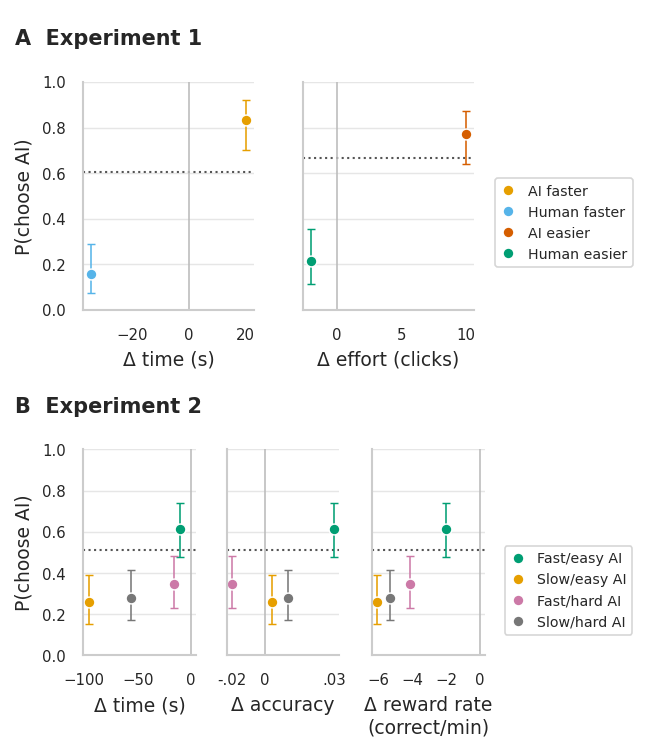

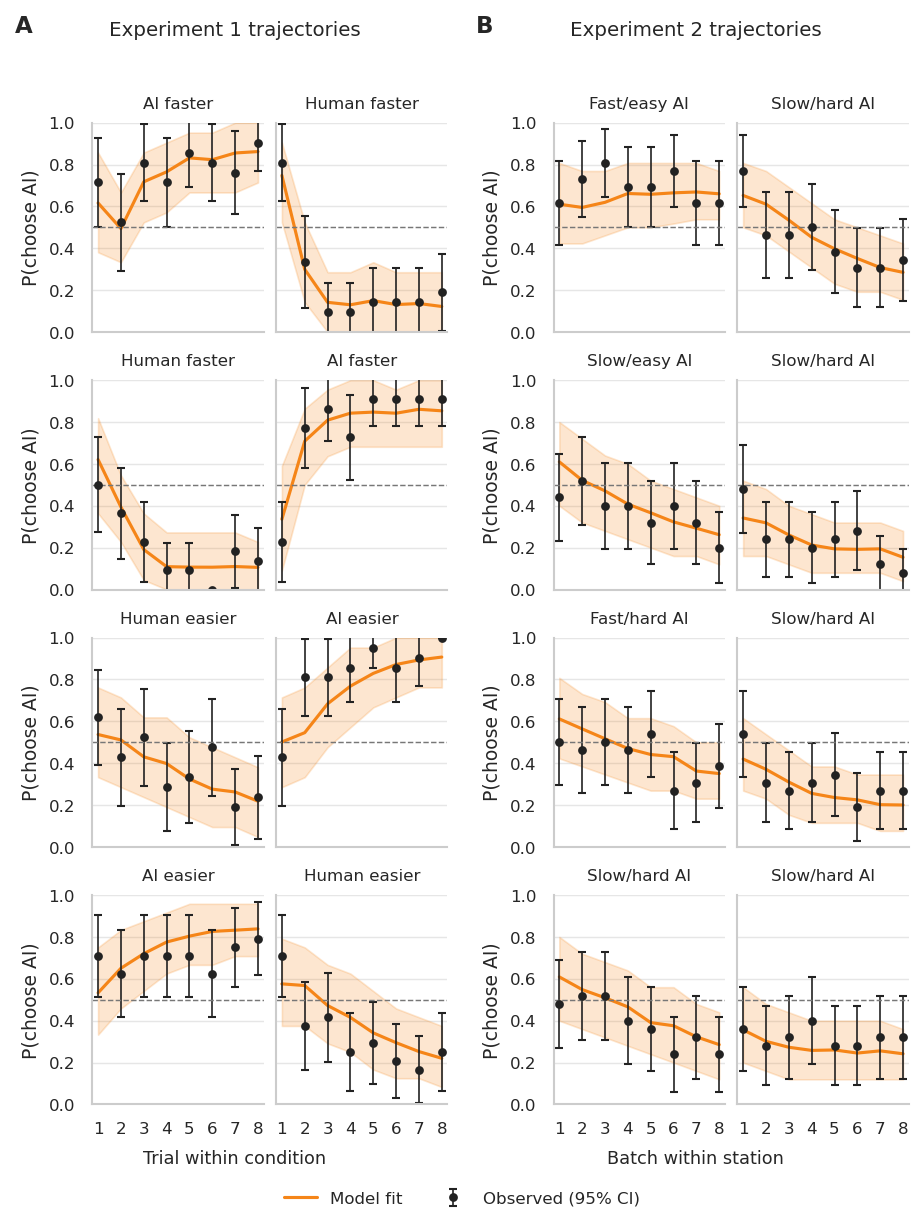

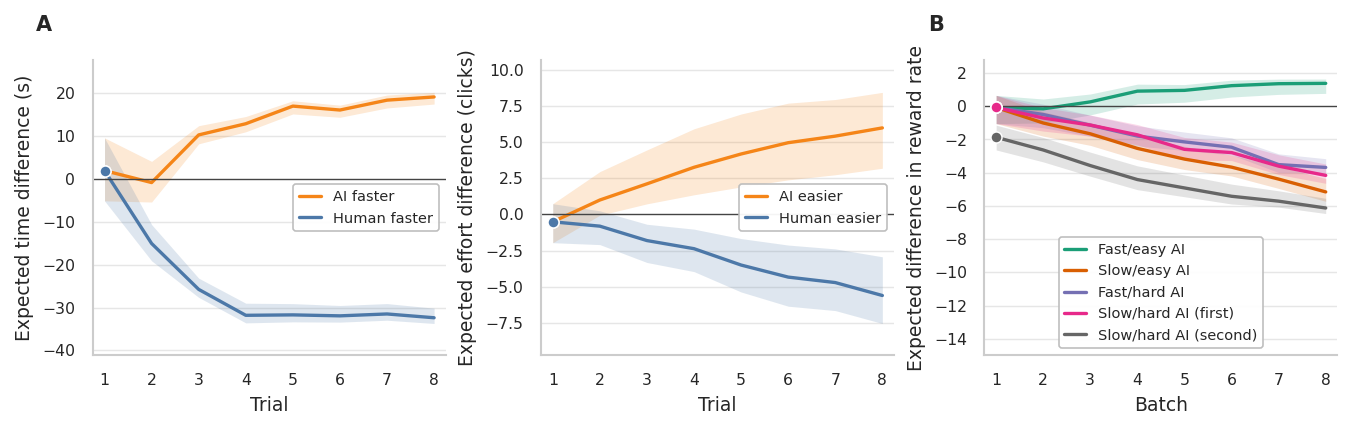

,experiment,condition,n,time_with_ai_mean,time_with_ai_sd,time_no_ai_mean,time_no_ai_sd,effort_with_ai_mean,effort_with_ai_sd,effort_no_ai_mean,effort_no_ai_sd
0,Experiment 1,AI faster,43,23.7934,4.7534,43.6056,3.9511,6.0000,NaN,12.0,NaN
1,Experiment 1,Human faster,43,50.0655,8.2808,17.9850,2.8675,6.0000,NaN,12.0,NaN
2,Experiment 1,AI easier,45,31.6425,4.4792,32.4777,3.4395,2.0000,NaN,12.0,NaN
3,Experiment 1,Human easier,45,39.7087,8.3061,37.6592,5.6007,6.0000,NaN,4.0,NaN
4,Experiment 2,Fast/easy AI,26,37.5903,14.8528,27.9372,15.1061,6.0926,2.4543,NaN,NaN
5,Experiment 2,Slow/easy AI,25,74.4278,17.2007,24.4859,6.3882,6.2882,3.1210,NaN,NaN
6,Experiment 2,Fast/hard AI,26,38.5722,12.8815,22.2977,6.3038,12.4839,7.4281,NaN,NaN
7,Experiment 2,Slow/hard AI,25,88.9410,20.3633,33.0058,19.6321,16.7006,7.9980,NaN,NaN


In [6]:
def generate_figures(show=True):
    experiment_1_time, experiment_1_effort, experiment_2 = load_data()
    build_table_1(experiment_1_time, experiment_1_effort, experiment_2).to_csv(
        OUT / "table_1.csv", index=False
    )
    figures = [
        figure_1(experiment_1_time, experiment_1_effort, experiment_2),
        figure_2(experiment_1_time, experiment_1_effort, experiment_2),
        figure_3(),
    ]
    if show:
        plt.show()
    else:
        for figure in figures:
            plt.close(figure)
    return figures


_figures = generate_figures(show=True)
pd.read_csv(OUT / "table_1.csv")
